# Forex-Datenanalyse: Quellenvergleich & Bereinigung

**Ziel:** Forex-Rohdaten aus drei Quellen (Yahoo Finance, EODHD, MetaTrader 5) systematisch analysieren, Datenqualitaet pruefen und Quellen vergleichen.

**Waehrungspaare:** EUR/USD, EUR/CHF, GBP/USD (MetaTrader nur EUR/USD)

**Schritte:**
1. Daten laden und Formate harmonisieren
2. Duplikate pruefen
3. Fehlende Tage identifizieren (quellenuebergreifend)
4. Preisabweichungen zwischen Quellen analysieren
5. MetaTrader M15 -> Daily Aggregation und Vergleich

## 1. Setup & Daten laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (14, 6)
pd.set_option("display.max_columns", None)

DATA_DIR = os.path.join("..", "..", "data", "raw", "forex")
PAIRS = ["EUR_USD", "EUR_CHF", "GBP_USD"]

print("Setup erfolgreich!")

Setup erfolgreich!


In [2]:
# Alle Forex-Daten laden und in einheitliches Format bringen
# Zielformat: DatetimeIndex (timezone-naive, auf Tage normalisiert), Spalten: open, high, low, close

def load_yahoo(pair):
    """Yahoo Finance CSV laden und normalisieren.
    
    Yahoo liefert Forex-Daten mit Zeitstempel 23:00 UTC (= Tagesende NY).
    Eintraege mit 23:00 UTC gehoeren zum naechsten Handelstag, daher runden
    wir auf den naechsten Tag auf statt normalize() zu verwenden.
    """
    pattern = os.path.join(DATA_DIR, "yahoo", f"{pair}_*.csv")
    files = sorted(glob.glob(pattern))
    df = pd.read_csv(files[-1], index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
    # Auf naechsten Tag aufrunden (ceil), damit 23:00 Sonntag -> Montag wird
    df.index = df.index.ceil("D")
    df.index.name = "date"
    df = df.rename(columns=str.lower)
    # Allfaellige Duplikate nach Aufrundung entfernen (erster Eintrag behalten)
    df = df[~df.index.duplicated(keep="first")]
    return df[["open", "high", "low", "close"]].copy()

def load_eodhd(pair):
    """EODHD CSV laden und normalisieren."""
    pattern = os.path.join(DATA_DIR, "eodhd", f"{pair}_*.csv")
    files = sorted(glob.glob(pattern))
    df = pd.read_csv(files[-1], index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index).normalize()
    df.index.name = "date"
    return df[["open", "high", "low", "close"]].copy()

def load_metatrader_daily():
    """MetaTrader Daily CSV laden und normalisieren."""
    path = os.path.join(DATA_DIR, "metatrader", "EURUSD_Daily_202201030000_202512260000.csv")
    df = pd.read_csv(path, sep="\t")
    df.columns = [c.strip("<>").lower() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], format="%Y.%m.%d")
    df = df.set_index("date")
    return df[["open", "high", "low", "close"]].copy()

# Daten laden
data = {}
for pair in PAIRS:
    data[pair] = {
        "yahoo": load_yahoo(pair),
        "eodhd": load_eodhd(pair),
    }

# MetaTrader nur fuer EUR/USD
data["EUR_USD"]["metatrader"] = load_metatrader_daily()

# Uebersicht
for pair in PAIRS:
    print(f"\n{'=' * 60}")
    print(f"{pair}")
    print(f"{'=' * 60}")
    for source, df in data[pair].items():
        weekends = (df.index.weekday >= 5).sum()
        print(f"  {source:12s}: {len(df):5d} Zeilen, {df.index.min().date()} bis {df.index.max().date()}, Wochenenden: {weekends}")


EUR_USD
  yahoo       :  1097 Zeilen, 2022-01-03 bis 2026-03-24, Wochenenden: 0
  eodhd       :  1384 Zeilen, 2022-01-02 bis 2026-03-24, Wochenenden: 282
  metatrader  :  1037 Zeilen, 2022-01-03 bis 2025-12-26, Wochenenden: 0

EUR_CHF
  yahoo       :  1097 Zeilen, 2022-01-03 bis 2026-03-24, Wochenenden: 0
  eodhd       :  1151 Zeilen, 2022-01-03 bis 2026-03-25, Wochenenden: 48

GBP_USD
  yahoo       :  1097 Zeilen, 2022-01-03 bis 2026-03-24, Wochenenden: 0
  eodhd       :  1387 Zeilen, 2022-01-02 bis 2026-03-24, Wochenenden: 285


## 2. Duplikate pruefen

Gibt es doppelte Datumseintraege innerhalb einer Quelle?

In [3]:
# 2.1 Duplikate im Index (doppelte Tage)
print("=== Duplikate im Datumsindex ===\n")
for pair in PAIRS:
    print(f"{pair}:")
    for source, df in data[pair].items():
        n_dupes = df.index.duplicated().sum()
        status = "KEINE" if n_dupes == 0 else f"{n_dupes} DUPLIKATE!"
        print(f"  {source:12s}: {status}")
        if n_dupes > 0:
            dupe_dates = df.index[df.index.duplicated(keep=False)]
            print(f"    Betroffene Tage: {sorted(set(dupe_dates.date))}")
    print()

=== Duplikate im Datumsindex ===

EUR_USD:
  yahoo       : KEINE
  eodhd       : KEINE
  metatrader  : KEINE

EUR_CHF:
  yahoo       : KEINE
  eodhd       : KEINE

GBP_USD:
  yahoo       : KEINE
  eodhd       : KEINE



In [4]:
# 2.2 Inhaltliche Duplikate (identische OHLC-Werte an verschiedenen Tagen)
print("=== Inhaltliche Duplikate (identische OHLC-Werte an verschiedenen Tagen) ===\n")
for pair in PAIRS:
    print(f"{pair}:")
    for source, df in data[pair].items():
        content_dupes = df.duplicated().sum()
        print(f"  {source:12s}: {content_dupes} identische Zeilen")
    print()

=== Inhaltliche Duplikate (identische OHLC-Werte an verschiedenen Tagen) ===

EUR_USD:
  yahoo       : 0 identische Zeilen
  eodhd       : 0 identische Zeilen
  metatrader  : 0 identische Zeilen

EUR_CHF:
  yahoo       : 0 identische Zeilen
  eodhd       : 1 identische Zeilen

GBP_USD:
  yahoo       : 0 identische Zeilen
  eodhd       : 0 identische Zeilen



## 3. Fehlende Tage - quellenuebergreifender Vergleich

Welche Tage sind in einer Quelle vorhanden, aber in einer anderen nicht? Wir vergleichen pro Waehrungspaar die Schnittmenge und Differenzmengen der Datumsindizes.

In [5]:
# 3.1 Uebersicht: Wochentage vs. Wochenenden pro Quelle
print("=== Wochentage vs. Wochenenden pro Quelle ===\n")
for pair in PAIRS:
    print(f"{pair}:")
    for source, df in data[pair].items():
        weekdays = (df.index.weekday < 5).sum()
        weekends = (df.index.weekday >= 5).sum()
        print(f"  {source:12s}: {weekdays:5d} Wochentage, {weekends:3d} Wochenenden")
    print()

=== Wochentage vs. Wochenenden pro Quelle ===

EUR_USD:
  yahoo       :  1097 Wochentage,   0 Wochenenden
  eodhd       :  1102 Wochentage, 282 Wochenenden
  metatrader  :  1037 Wochentage,   0 Wochenenden

EUR_CHF:
  yahoo       :  1097 Wochentage,   0 Wochenenden
  eodhd       :  1103 Wochentage,  48 Wochenenden

GBP_USD:
  yahoo       :  1097 Wochentage,   0 Wochenenden
  eodhd       :  1102 Wochentage, 285 Wochenenden



In [6]:
# 3.2 Datumsvergleich: Welche Tage fehlen wo?
print("=== Quellenuebergreifender Datumsvergleich ===\n")

for pair in PAIRS:
    sources = data[pair]
    source_names = list(sources.keys())
    
    print(f"{'=' * 60}")
    print(f"{pair}")
    print(f"{'=' * 60}")
    
    # Paarweiser Vergleich
    for i, src_a in enumerate(source_names):
        for src_b in source_names[i+1:]:
            dates_a = set(sources[src_a].index)
            dates_b = set(sources[src_b].index)
            
            common = dates_a & dates_b
            only_a = sorted(dates_a - dates_b)
            only_b = sorted(dates_b - dates_a)
            
            print(f"\n  {src_a} vs. {src_b}:")
            print(f"    Gemeinsame Tage:        {len(common)}")
            print(f"    Nur in {src_a:12s}:  {len(only_a)}")
            print(f"    Nur in {src_b:12s}:  {len(only_b)}")
            
            # Wochenende-Anteil in den Differenzen
            if only_a:
                we_a = sum(1 for d in only_a if d.weekday() >= 5)
                wd_a = len(only_a) - we_a
                print(f"      -> davon Wochenenden: {we_a}, Wochentage: {wd_a}")
                if wd_a > 0 and wd_a <= 20:
                    print(f"      -> Fehlende Wochentage: {[d.date() for d in only_a if d.weekday() < 5]}")
            if only_b:
                we_b = sum(1 for d in only_b if d.weekday() >= 5)
                wd_b = len(only_b) - we_b
                print(f"      -> davon Wochenenden: {we_b}, Wochentage: {wd_b}")
                if wd_b > 0 and wd_b <= 20:
                    print(f"      -> Fehlende Wochentage: {[d.date() for d in only_b if d.weekday() < 5]}")
    print()

=== Quellenuebergreifender Datumsvergleich ===

EUR_USD

  yahoo vs. eodhd:
    Gemeinsame Tage:        1097
    Nur in yahoo       :  0
    Nur in eodhd       :  287
      -> davon Wochenenden: 282, Wochentage: 5
      -> Fehlende Wochentage: [datetime.date(2025, 1, 1), datetime.date(2025, 4, 18), datetime.date(2025, 4, 21), datetime.date(2025, 12, 25), datetime.date(2026, 1, 1)]

  yahoo vs. metatrader:
    Gemeinsame Tage:        1035
    Nur in yahoo       :  62
    Nur in metatrader  :  2
      -> davon Wochenenden: 0, Wochentage: 62
      -> davon Wochenenden: 0, Wochentage: 2
      -> Fehlende Wochentage: [datetime.date(2025, 4, 18), datetime.date(2025, 4, 21)]

  eodhd vs. metatrader:
    Gemeinsame Tage:        1037
    Nur in eodhd       :  347
    Nur in metatrader  :  0
      -> davon Wochenenden: 282, Wochentage: 65

EUR_CHF

  yahoo vs. eodhd:
    Gemeinsame Tage:        1097
    Nur in yahoo       :  0
    Nur in eodhd       :  54
      -> davon Wochenenden: 48, Wochenta

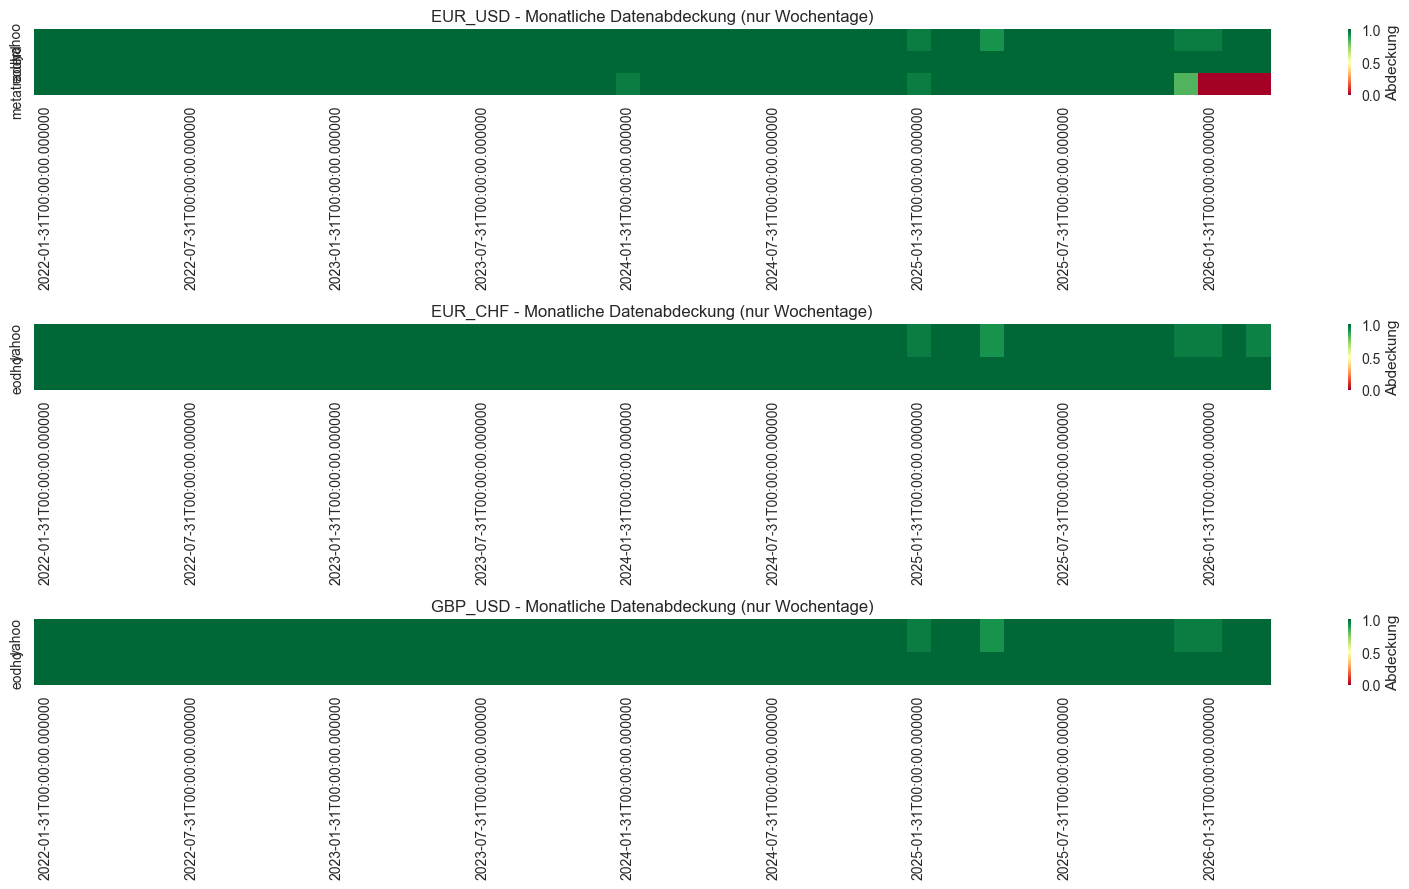

In [7]:
# 3.3 Visualisierung: Datenabdeckung pro Quelle (Heatmap)
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(16, 3 * len(PAIRS)))

for ax, pair in zip(axes, PAIRS):
    sources = data[pair]
    
    # Alle Daten auf gemeinsamen Bereich
    all_dates = sorted(set().union(*(set(df.index) for df in sources.values())))
    date_range = pd.date_range(min(all_dates), max(all_dates), freq="D")
    
    # Matrix: 1 = vorhanden, 0 = fehlt
    coverage = pd.DataFrame(index=date_range)
    for source, df in sources.items():
        coverage[source] = coverage.index.isin(df.index).astype(int)
    
    # Nur Wochentage anzeigen
    coverage_wd = coverage[coverage.index.weekday < 5]
    
    # Monatliche Aggregation: Anteil verfuegbarer Tage
    monthly = coverage_wd.resample("ME").mean()
    
    sns.heatmap(monthly.T, ax=ax, cmap="RdYlGn", vmin=0, vmax=1, 
                xticklabels=6, yticklabels=True, cbar_kws={"label": "Abdeckung"})
    ax.set_title(f"{pair} - Monatliche Datenabdeckung (nur Wochentage)", fontsize=12)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

## 4. Fehlende Inhalte (NaN-Werte)

Gibt es Zeilen die zwar existieren, aber fehlende Werte in den OHLC-Spalten haben?

In [8]:
# 4.1 Fehlende Werte pro Quelle und Spalte
print("=== Fehlende Werte (NaN) in OHLC-Spalten ===\n")
for pair in PAIRS:
    print(f"{pair}:")
    for source, df in data[pair].items():
        missing = df.isnull().sum()
        total_missing = missing.sum()
        if total_missing == 0:
            print(f"  {source:12s}: Keine fehlenden Werte")
        else:
            print(f"  {source:12s}: {total_missing} fehlende Werte")
            for col in df.columns:
                if missing[col] > 0:
                    print(f"    {col}: {missing[col]} ({missing[col]/len(df)*100:.1f}%)")
    print()

=== Fehlende Werte (NaN) in OHLC-Spalten ===

EUR_USD:
  yahoo       : Keine fehlenden Werte
  eodhd       : Keine fehlenden Werte
  metatrader  : Keine fehlenden Werte

EUR_CHF:
  yahoo       : Keine fehlenden Werte
  eodhd       : Keine fehlenden Werte

GBP_USD:
  yahoo       : Keine fehlenden Werte
  eodhd       : Keine fehlenden Werte



## 5. Preisabweichungen zwischen Quellen

Fuer die gemeinsamen Tage: Wie stark weichen die Close-Preise voneinander ab? Das zeigt uns ob die Quellen konsistent sind oder ob es systematische Unterschiede gibt (z.B. durch Zeitzonenverschiebung).

In [9]:
# 5.1 Close-Preise zusammenfuehren und Abweichungen berechnen
print("=== Preisabweichungen (Close) zwischen Quellen ===\n")

comparisons = {}

for pair in PAIRS:
    sources = data[pair]
    source_names = list(sources.keys())
    
    # Close-Preise zusammenfuehren (inner join = nur gemeinsame Tage)
    close_df = pd.DataFrame()
    for source, df in sources.items():
        close_df[source] = df["close"]
    
    close_df = close_df.dropna()
    comparisons[pair] = close_df
    
    print(f"{'=' * 60}")
    print(f"{pair} ({len(close_df)} gemeinsame Tage)")
    print(f"{'=' * 60}")
    
    # Paarweiser Vergleich
    for i, src_a in enumerate(source_names):
        for src_b in source_names[i+1:]:
            if src_a in close_df.columns and src_b in close_df.columns:
                diff = close_df[src_a] - close_df[src_b]
                pct_diff = (diff / close_df[src_b] * 100)
                
                print(f"\n  {src_a} - {src_b}:")
                print(f"    Mittlere Abweichung:     {diff.mean():.6f} ({pct_diff.mean():.4f}%)")
                print(f"    Std. Abweichung:         {diff.std():.6f}")
                print(f"    Max. Abweichung:         {diff.abs().max():.6f} ({pct_diff.abs().max():.4f}%)")
                print(f"    Median Abweichung:       {diff.median():.6f}")
                
                # Tage mit groesster Abweichung
                worst_days = diff.abs().nlargest(5)
                print(f"    Top-5 groesste Abweichungen:")
                for date, val in worst_days.items():
                    print(f"      {date.date()}: {val:+.6f} ({src_a}: {close_df.loc[date, src_a]:.5f}, {src_b}: {close_df.loc[date, src_b]:.5f})")
    print()

=== Preisabweichungen (Close) zwischen Quellen ===

EUR_USD (1035 gemeinsame Tage)

  yahoo - eodhd:
    Mittlere Abweichung:     -0.000084 (-0.0061%)
    Std. Abweichung:         0.005848
    Max. Abweichung:         0.040794 (3.5910%)
    Median Abweichung:       0.000000
    Top-5 groesste Abweichungen:
      2025-04-10: +0.040794 (yahoo: 1.09521, eodhd: 1.13600)
      2025-03-04: +0.030496 (yahoo: 1.04850, eodhd: 1.07900)
      2025-04-02: +0.025501 (yahoo: 1.07960, eodhd: 1.10510)
      2025-04-09: +0.022156 (yahoo: 1.09804, eodhd: 1.12020)
      2025-03-03: +0.021215 (yahoo: 1.04138, eodhd: 1.06260)

  yahoo - metatrader:
    Mittlere Abweichung:     0.000222 (0.0215%)
    Std. Abweichung:         0.005260
    Max. Abweichung:         0.024204 (2.1622%)
    Median Abweichung:       0.000283
    Top-5 groesste Abweichungen:
      2025-04-10: +0.024204 (yahoo: 1.09521, metatrader: 1.11941)
      2022-11-04: +0.020977 (yahoo: 0.97496, metatrader: 0.99594)
      2024-11-06: +0.020906

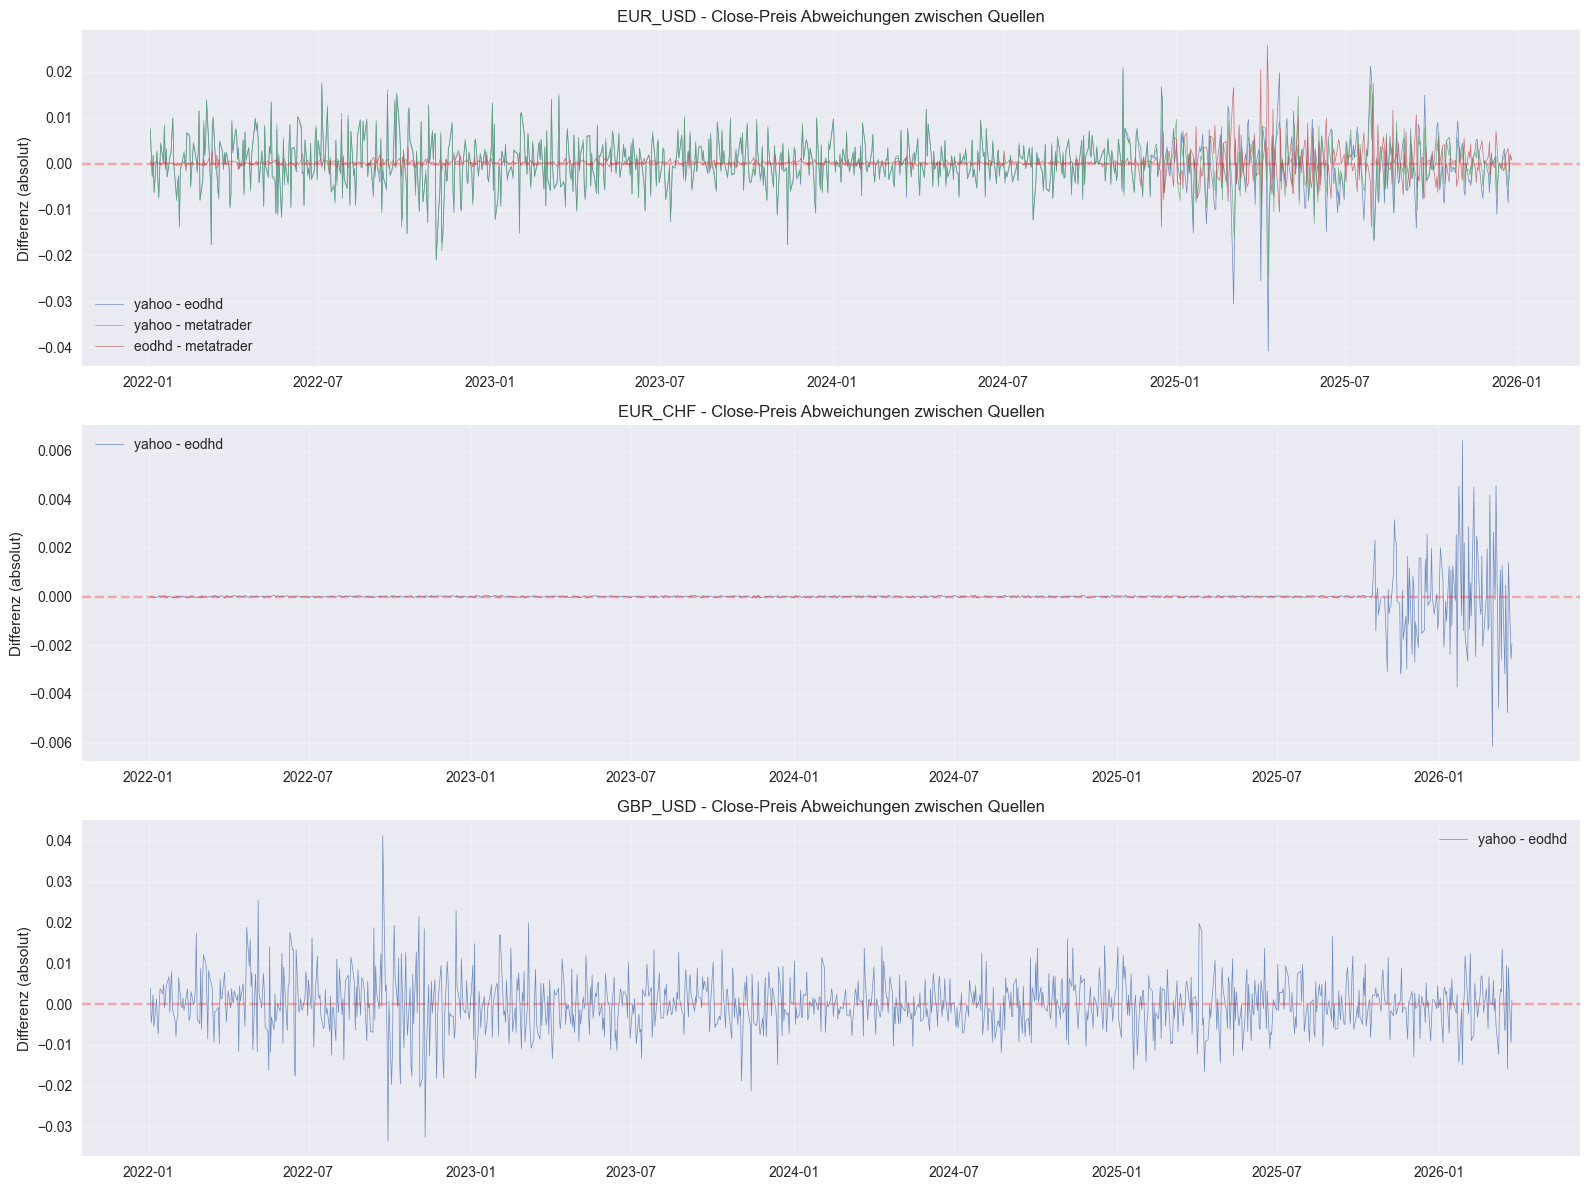

In [10]:
# 5.2 Visualisierung: Preisabweichungen ueber Zeit
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(16, 4 * len(PAIRS)), sharex=False)

for ax, pair in zip(axes, PAIRS):
    close_df = comparisons[pair]
    source_names = list(data[pair].keys())
    
    # Alle paarweisen Differenzen plotten
    for i, src_a in enumerate(source_names):
        for src_b in source_names[i+1:]:
            if src_a in close_df.columns and src_b in close_df.columns:
                diff = close_df[src_a] - close_df[src_b]
                ax.plot(diff.index, diff, linewidth=0.5, alpha=0.8, label=f"{src_a} - {src_b}")
    
    ax.axhline(y=0, color="red", linestyle="--", alpha=0.3)
    ax.set_title(f"{pair} - Close-Preis Abweichungen zwischen Quellen", fontsize=12)
    ax.set_ylabel("Differenz (absolut)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# 5.3 Korrelation zwischen den Quellen (Sanity Check)
print("=== Korrelation der Close-Preise zwischen Quellen ===\n")
for pair in PAIRS:
    close_df = comparisons[pair]
    print(f"{pair}:")
    corr = close_df.corr()
    display(corr.round(8))
    print()

=== Korrelation der Close-Preise zwischen Quellen ===

EUR_USD:


,yahoo,eodhd,metatrader
yahoo,1.000000,0.991895,0.993433
eodhd,0.991895,1.000000,0.998414
metatrader,0.993433,0.998414,1.000000



EUR_CHF:


,yahoo,eodhd
yahoo,1.000000,0.999799
eodhd,0.999799,1.000000



GBP_USD:


,yahoo,eodhd
yahoo,1.000000,0.993232
eodhd,0.993232,1.000000


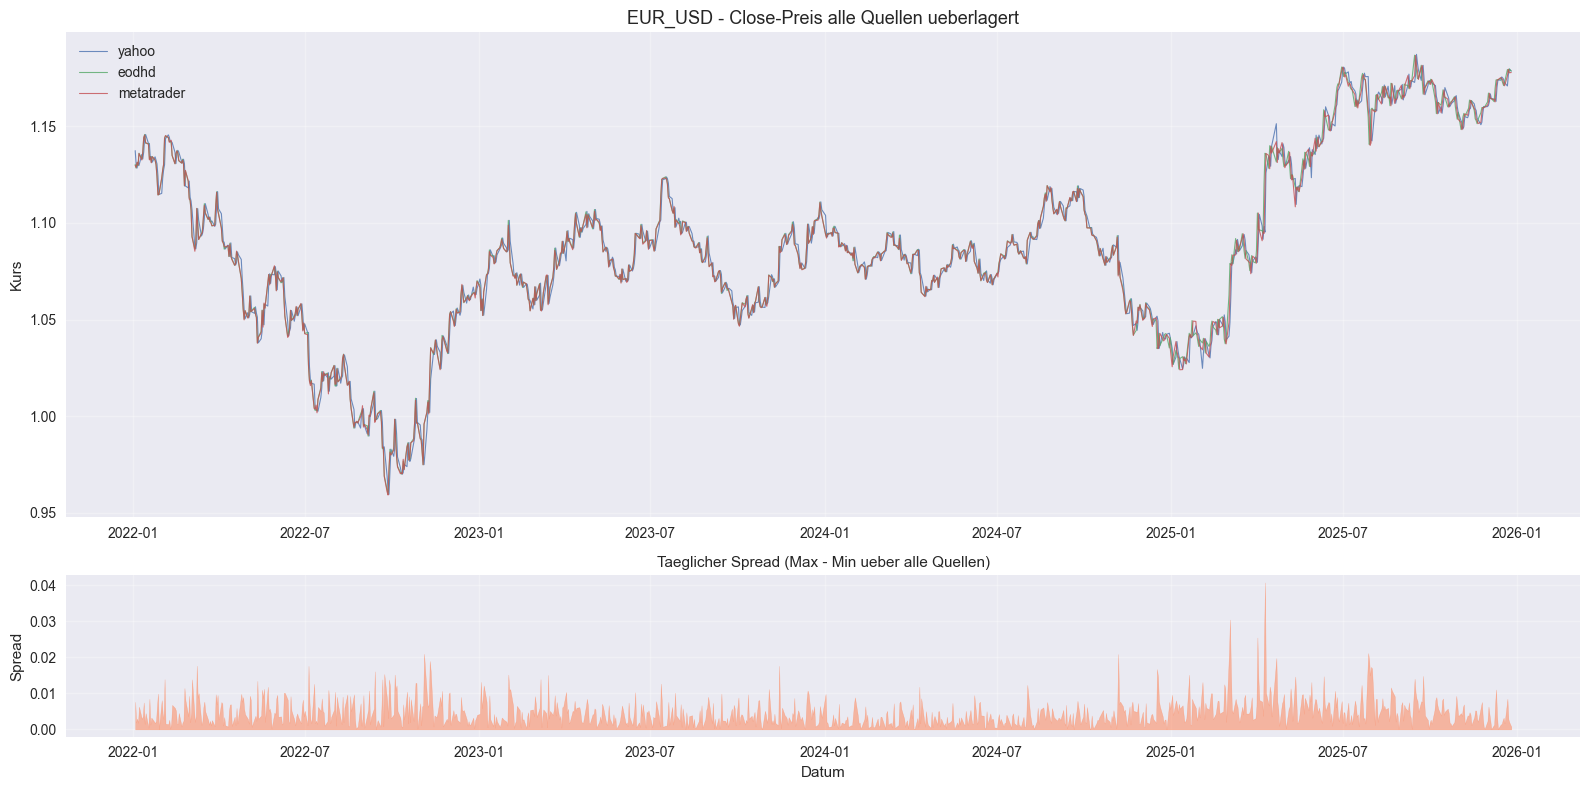

Mittlerer taeglicher Spread: 0.004722
Maximaler taeglicher Spread: 0.040794
Tage mit Spread > 0.01:      85


In [12]:
# 5.4 Detailansicht: Kursverlauf ueberlagert (EUR/USD als Beispiel)
pair = "EUR_USD"
close_df = comparisons[pair]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={"height_ratios": [3, 1]})

# Oben: Kursverlauf ueberlagert
for source in close_df.columns:
    ax1.plot(close_df.index, close_df[source], linewidth=0.8, alpha=0.8, label=source)
ax1.set_title(f"{pair} - Close-Preis alle Quellen ueberlagert", fontsize=13)
ax1.set_ylabel("Kurs")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Unten: Spread (Max - Min ueber alle Quellen pro Tag)
daily_spread = close_df.max(axis=1) - close_df.min(axis=1)
ax2.fill_between(daily_spread.index, daily_spread, alpha=0.5, color="coral")
ax2.set_title("Taeglicher Spread (Max - Min ueber alle Quellen)", fontsize=11)
ax2.set_ylabel("Spread")
ax2.set_xlabel("Datum")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mittlerer taeglicher Spread: {daily_spread.mean():.6f}")
print(f"Maximaler taeglicher Spread: {daily_spread.max():.6f}")
print(f"Tage mit Spread > 0.01:      {(daily_spread > 0.01).sum()}")

## 6. MetaTrader M15 -> Daily Aggregation

Die MetaTrader M15-Daten (15-Minuten-Intervall, ~99'000 Zeilen) werden auf Tagesbasis aggregiert:
- **Open**: Erster Open-Wert des Tages
- **High**: Maximum aller Highs des Tages
- **Low**: Minimum aller Lows des Tages
- **Close**: Letzter Close-Wert des Tages

Anschliessend vergleichen wir die aggregierten Werte mit den originalen MetaTrader-Daily-Daten, um die Korrektheit der Aggregation zu ueberpruefen.

In [13]:
# 6.1 M15-Daten laden
mt5_m15_path = os.path.join(DATA_DIR, "metatrader", "EURUSD_M15_202201030000_202512260100.csv")
mt5_m15 = pd.read_csv(mt5_m15_path, sep="\t")
mt5_m15.columns = [c.strip("<>").lower() for c in mt5_m15.columns]
mt5_m15["datetime"] = pd.to_datetime(mt5_m15["date"] + " " + mt5_m15["time"], format="%Y.%m.%d %H:%M:%S")
mt5_m15 = mt5_m15.set_index("datetime")
mt5_m15["trade_date"] = mt5_m15.index.normalize()

print(f"M15 Rohdaten: {len(mt5_m15)} Zeilen")
print(f"Zeitraum: {mt5_m15.index.min()} bis {mt5_m15.index.max()}")
print(f"Anzahl Handelstage: {mt5_m15['trade_date'].nunique()}")
mt5_m15[["open", "high", "low", "close", "tickvol"]].head()

M15 Rohdaten: 99011 Zeilen
Zeitraum: 2022-01-03 00:00:00 bis 2025-12-26 01:00:00
Anzahl Handelstage: 1037


,open,high,low,close,tickvol
datetime,,,,,
2022-01-03 00:00:00,1.13693,1.13729,1.13645,1.13713,98
2022-01-03 00:15:00,1.13708,1.13723,1.13688,1.13708,104
2022-01-03 00:30:00,1.13705,1.13734,1.13699,1.13731,146
2022-01-03 00:45:00,1.13731,1.13742,1.13718,1.13726,223
2022-01-03 01:00:00,1.13725,1.13778,1.13717,1.13721,612


In [14]:
# 6.2 Aggregation: M15 -> Daily OHLC
mt5_m15_daily = mt5_m15.groupby("trade_date").agg(
    open=("open", "first"),
    high=("high", "max"),
    low=("low", "min"),
    close=("close", "last"),
    tickvol=("tickvol", "sum"),
    n_bars=("close", "count"),
).rename_axis("date")

print(f"Aggregierte Tage: {len(mt5_m15_daily)}")
print(f"\nAnzahl M15-Bars pro Tag:")
print(f"  Mittelwert: {mt5_m15_daily['n_bars'].mean():.1f}")
print(f"  Min:        {mt5_m15_daily['n_bars'].min()} (erwartet 96 fuer 24h)")
print(f"  Max:        {mt5_m15_daily['n_bars'].max()}")
mt5_m15_daily.head()

Aggregierte Tage: 1037

Anzahl M15-Bars pro Tag:
  Mittelwert: 95.5
  Min:        1 (erwartet 96 fuer 24h)
  Max:        96


,open,high,low,close,tickvol,n_bars
date,,,,,,
2022-01-03,1.13693,1.13778,1.12795,1.12971,53813,96
2022-01-04,1.12961,1.13226,1.12723,1.12862,62525,96
2022-01-05,1.12852,1.13466,1.12765,1.13135,61289,96
2022-01-06,1.13111,1.13316,1.12846,1.12976,67251,96
2022-01-07,1.12960,1.13647,1.12901,1.13590,49836,96


In [15]:
# 6.3 Vergleich: M15-Aggregiert vs. Original-Daily
mt5_orig = data["EUR_USD"]["metatrader"]

# Zusammenfuehren auf gemeinsame Tage
compare_mt5 = pd.DataFrame({
    "orig_open": mt5_orig["open"],
    "orig_high": mt5_orig["high"],
    "orig_low": mt5_orig["low"],
    "orig_close": mt5_orig["close"],
    "agg_open": mt5_m15_daily["open"],
    "agg_high": mt5_m15_daily["high"],
    "agg_low": mt5_m15_daily["low"],
    "agg_close": mt5_m15_daily["close"],
}).dropna()

print(f"Gemeinsame Tage: {len(compare_mt5)}\n")

# Differenzen berechnen
for col in ["open", "high", "low", "close"]:
    diff = compare_mt5[f"agg_{col}"] - compare_mt5[f"orig_{col}"]
    exact_match = (diff == 0).sum()
    print(f"{col.upper()}:")
    print(f"  Exakte Uebereinstimmung: {exact_match}/{len(compare_mt5)} ({exact_match/len(compare_mt5)*100:.1f}%)")
    print(f"  Mittlere Abweichung:     {diff.mean():.7f}")
    print(f"  Max. Abweichung:         {diff.abs().max():.7f}")
    print()

Gemeinsame Tage: 1037

OPEN:
  Exakte Uebereinstimmung: 1037/1037 (100.0%)
  Mittlere Abweichung:     0.0000000
  Max. Abweichung:         0.0000000

HIGH:
  Exakte Uebereinstimmung: 1037/1037 (100.0%)
  Mittlere Abweichung:     0.0000000
  Max. Abweichung:         0.0000000

LOW:
  Exakte Uebereinstimmung: 1037/1037 (100.0%)
  Mittlere Abweichung:     0.0000000
  Max. Abweichung:         0.0000000

CLOSE:
  Exakte Uebereinstimmung: 1037/1037 (100.0%)
  Mittlere Abweichung:     0.0000000
  Max. Abweichung:         0.0000000



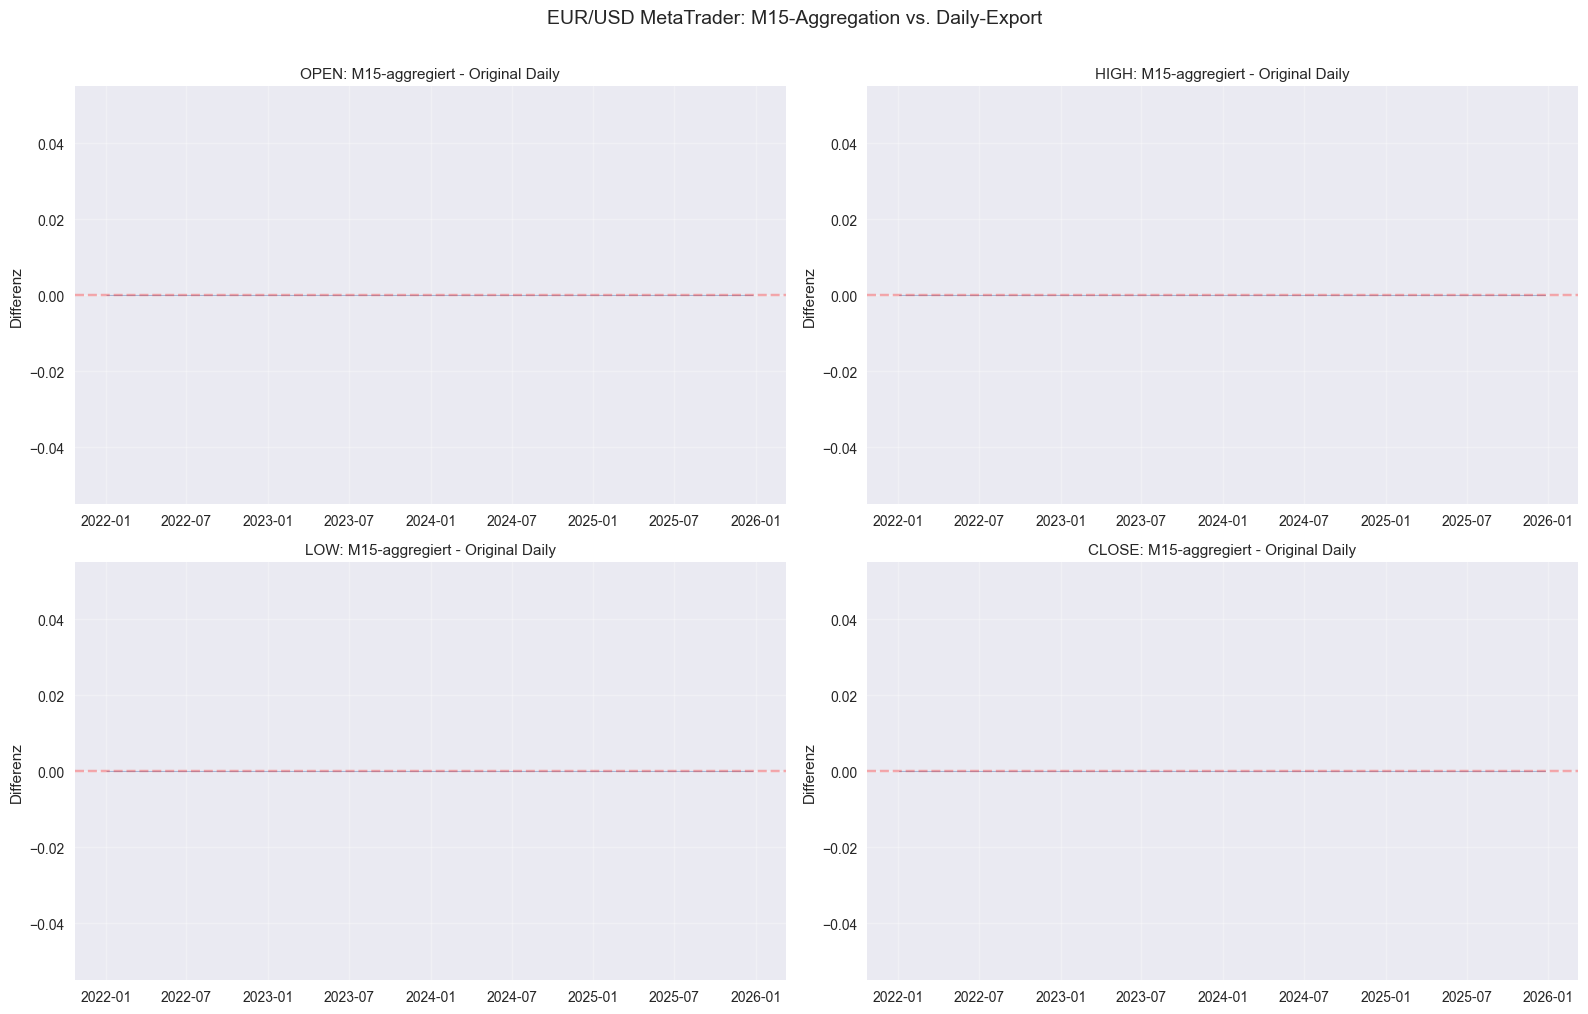

In [16]:
# 6.4 Visualisierung: M15-Aggregiert vs. Original-Daily
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flat, ["open", "high", "low", "close"]):
    diff = compare_mt5[f"agg_{col}"] - compare_mt5[f"orig_{col}"]
    
    ax.plot(diff.index, diff, linewidth=0.5, alpha=0.7)
    ax.axhline(y=0, color="red", linestyle="--", alpha=0.3)
    ax.set_title(f"{col.upper()}: M15-aggregiert - Original Daily", fontsize=11)
    ax.set_ylabel("Differenz")
    ax.grid(True, alpha=0.3)

plt.suptitle("EUR/USD MetaTrader: M15-Aggregation vs. Daily-Export", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

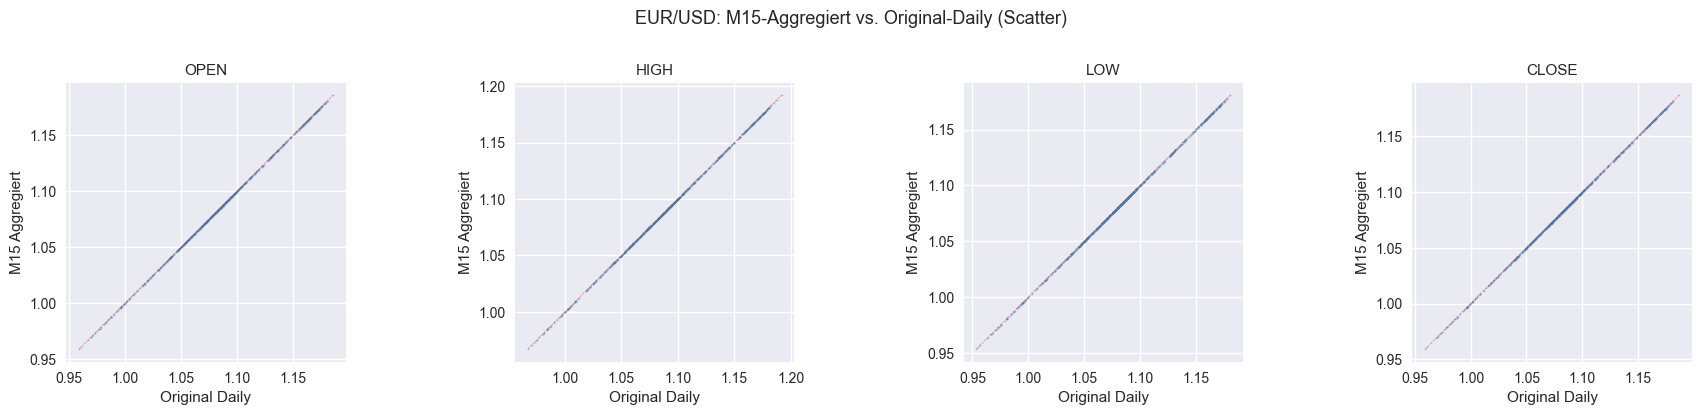

In [17]:
# 6.5 Scatter-Plot: Aggregiert vs. Original (sollte perfekt auf der Diagonale liegen)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, ["open", "high", "low", "close"]):
    ax.scatter(compare_mt5[f"orig_{col}"], compare_mt5[f"agg_{col}"], 
               s=1, alpha=0.3, color="steelblue")
    
    # Diagonale einzeichnen
    lim = [compare_mt5[[f"orig_{col}", f"agg_{col}"]].min().min(),
           compare_mt5[[f"orig_{col}", f"agg_{col}"]].max().max()]
    ax.plot(lim, lim, "r--", linewidth=0.5, alpha=0.5)
    
    ax.set_title(col.upper(), fontsize=11)
    ax.set_xlabel("Original Daily")
    ax.set_ylabel("M15 Aggregiert")
    ax.set_aspect("equal")

plt.suptitle("EUR/USD: M15-Aggregiert vs. Original-Daily (Scatter)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Kombiniertes CSV exportieren

Alle Quellen und Waehrungspaare werden in ein einziges CSV zusammengefuehrt. Jede Zeile ist ein Handelstag, die Spalten enthalten die OHLC-Werte pro Quelle mit Praefix (z.B. `yahoo_open`, `eodhd_close`). Zusaetzlich werden Hilfsspalten erstellt:
- `weekday`: Wochentag (0=Mo, 6=So)
- `is_weekend`: Flag fuer Wochenende
- `n_sources`: Anzahl Quellen die fuer diesen Tag Daten haben
- `has_gap`: True wenn nicht alle Quellen Daten haben

In [18]:
# 7.1 Kombiniertes DataFrame erstellen
PROCESSED_DIR = os.path.join("..", "..", "data", "processed", "forex")
os.makedirs(PROCESSED_DIR, exist_ok=True)

all_dfs = []

for pair in PAIRS:
    sources = data[pair]
    
    # Alle Close-Preise mit Quellen-Praefix zusammenfuehren (outer join = alle Tage)
    pair_df = pd.DataFrame()
    for source, df in sources.items():
        for col in ["open", "high", "low", "close"]:
            pair_df[f"{source}_{col}"] = df[col]
    
    # Outer join: Alle Tage aus allen Quellen
    pair_df = pair_df.sort_index()
    pair_df.index.name = "date"
    
    # Metadaten hinzufuegen
    pair_df["pair"] = pair
    pair_df["weekday"] = pair_df.index.weekday
    pair_df["weekday_name"] = pair_df.index.strftime("%a")
    pair_df["is_weekend"] = pair_df["weekday"] >= 5
    
    # Anzahl Quellen mit Daten pro Tag
    source_names = list(sources.keys())
    close_cols = [f"{s}_close" for s in source_names]
    pair_df["n_sources"] = pair_df[close_cols].notna().sum(axis=1)
    pair_df["has_gap"] = pair_df["n_sources"] < len(source_names)
    
    all_dfs.append(pair_df)
    
    # Zusammenfassung
    total = len(pair_df)
    with_gap = pair_df["has_gap"].sum()
    weekday_gaps = pair_df[~pair_df["is_weekend"] & pair_df["has_gap"]]
    print(f"{pair}:")
    print(f"  Total Tage:          {total}")
    print(f"  Tage mit Luecken:    {with_gap} ({with_gap/total*100:.1f}%)")
    print(f"  Wochentag-Luecken:   {len(weekday_gaps)}")
    print(f"  Wochenend-Eintraege: {pair_df['is_weekend'].sum()}")
    print()

# Alles zusammenfuegen
df_combined = pd.concat(all_dfs)
df_combined = df_combined.sort_values(["pair", "date"])

print(f"\nKombiniertes DataFrame: {len(df_combined)} Zeilen, {df_combined.shape[1]} Spalten")
print(f"Spalten: {df_combined.columns.tolist()}")

EUR_USD:
  Total Tage:          1097
  Tage mit Luecken:    62 (5.7%)
  Wochentag-Luecken:   62
  Wochenend-Eintraege: 0

EUR_CHF:
  Total Tage:          1097
  Tage mit Luecken:    0 (0.0%)
  Wochentag-Luecken:   0
  Wochenend-Eintraege: 0

GBP_USD:
  Total Tage:          1097
  Tage mit Luecken:    0 (0.0%)
  Wochentag-Luecken:   0
  Wochenend-Eintraege: 0


Kombiniertes DataFrame: 3291 Zeilen, 18 Spalten
Spalten: ['yahoo_open', 'yahoo_high', 'yahoo_low', 'yahoo_close', 'eodhd_open', 'eodhd_high', 'eodhd_low', 'eodhd_close', 'metatrader_open', 'metatrader_high', 'metatrader_low', 'metatrader_close', 'pair', 'weekday', 'weekday_name', 'is_weekend', 'n_sources', 'has_gap']


In [19]:
# 7.2 Detailansicht: Tage mit Luecken (Wochentage)
print("=== Wochentag-Luecken: Tage wo nicht alle Quellen Daten haben ===\n")

for pair in PAIRS:
    pair_data = df_combined[df_combined["pair"] == pair]
    gaps = pair_data[~pair_data["is_weekend"] & pair_data["has_gap"]]
    
    if len(gaps) == 0:
        print(f"{pair}: Keine Wochentag-Luecken")
    else:
        print(f"{pair}: {len(gaps)} Wochentag-Luecken")
        source_names = list(data[pair].keys())
        close_cols = [f"{s}_close" for s in source_names]
        
        # Zeige welche Quelle fehlt
        for date, row in gaps.iterrows():
            missing = [s for s in source_names if pd.isna(row[f"{s}_close"])]
            present = [s for s in source_names if pd.notna(row[f"{s}_close"])]
            print(f"  {date.date()} ({row['weekday_name']}): fehlt in {missing}, vorhanden in {present}")
    print()

=== Wochentag-Luecken: Tage wo nicht alle Quellen Daten haben ===

EUR_USD: 62 Wochentag-Luecken
  2024-01-01 (Mon): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2025-12-29 (Mon): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2025-12-30 (Tue): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2025-12-31 (Wed): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2026-01-02 (Fri): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2026-01-05 (Mon): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2026-01-06 (Tue): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2026-01-07 (Wed): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2026-01-08 (Thu): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2026-01-09 (Fri): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2026-01-12 (Mon): fehlt in ['metatrader'], vorhanden in ['yahoo', 'eodhd']
  2026-01-13 (Tue): fehlt in ['metatrader'], vorhanden i

In [20]:
# 7.3 Als CSV speichern
output_path = os.path.join(PROCESSED_DIR, "forex_alle_quellen_kombiniert.csv")
df_combined.to_csv(output_path)
print(f"Gespeichert: {output_path}")
print(f"Groesse: {os.path.getsize(output_path) / 1024:.1f} KB")
print(f"Zeilen: {len(df_combined)}, Spalten: {df_combined.shape[1]}")

# Preview
print(f"\nBeispiel (EUR_USD, erste 10 Tage):")
preview = df_combined[df_combined["pair"] == "EUR_USD"].head(10)
display(preview)

Gespeichert: ../../data/processed/forex/forex_alle_quellen_kombiniert.csv
Groesse: 495.0 KB
Zeilen: 3291, Spalten: 18

Beispiel (EUR_USD, erste 10 Tage):


,yahoo_open,yahoo_high,yahoo_low,yahoo_close,eodhd_open,eodhd_high,eodhd_low,eodhd_close,metatrader_open,metatrader_high,metatrader_low,metatrader_close,pair,weekday,weekday_name,is_weekend,n_sources,has_gap
date,,,,,,,,,,,,,,,,,,
2022-01-03,1.137385,1.137592,1.128541,1.137346,1.1373,1.1376,1.1280,1.1302,1.13693,1.13778,1.12795,1.12971,EUR_USD,0,Mon,False,3,False
2022-01-04,1.130199,1.132300,1.127345,1.130224,1.1302,1.1323,1.1273,1.1283,1.12961,1.13226,1.12723,1.12862,EUR_USD,1,Tue,False,3,False
2022-01-05,1.128541,1.134559,1.127764,1.128363,1.1283,1.1347,1.1277,1.1311,1.12852,1.13466,1.12765,1.13135,EUR_USD,2,Wed,False,3,False
2022-01-06,1.131222,1.133067,1.128554,1.131350,1.1311,1.1332,1.1285,1.1295,1.13111,1.13316,1.12846,1.12976,EUR_USD,3,Thu,False,3,False
2022-01-07,1.129586,1.135976,1.129050,1.129688,1.1295,1.1365,1.1290,1.1360,1.12960,1.13647,1.12901,1.13590,EUR_USD,4,Fri,False,3,False
2022-01-10,1.135344,1.135976,1.128834,1.135396,1.1354,1.1358,1.1285,1.1330,1.13550,1.13599,1.12853,1.13252,EUR_USD,0,Mon,False,3,False
2022-01-11,1.133273,1.136900,1.131554,1.133042,1.1330,1.1375,1.1313,1.1366,1.13230,1.13753,1.13131,1.13666,EUR_USD,1,Tue,False,3,False
2022-01-12,1.137010,1.143300,1.135576,1.136648,1.1366,1.1453,1.1355,1.1440,1.13655,1.14528,1.13545,1.14411,EUR_USD,2,Wed,False,3,False
2022-01-13,1.143981,1.147908,1.143641,1.144165,1.1440,1.1482,1.1436,1.1457,1.14402,1.14817,1.14357,1.14539,EUR_USD,3,Thu,False,3,False


## Erkenntnisse

**Warum hat EODHD mehr Tage als Yahoo/MetaTrader?**
- EODHD liefert **Sonntags-Daten** (Forex-Markt oeffnet Sonntag Abend in Asien/Nahost). Yahoo und MetaTrader liefern nur Mo-Fr.
- Samstage fehlen bei allen Quellen (Markt geschlossen).
- An Wochentagen stimmen die Quellen ueberein, mit Ausnahme einzelner Feiertage die Yahoo nicht liefert aber EODHD schon.

**Wie soll man damit umgehen?**
- Fuer die Analyse: Nur Wochentag-Daten (Mo-Fr) verwenden und Wochenend-Eintraege von EODHD ignorieren
- Alternativ: EODHD-Sonntagsdaten dem Montag zuordnen (als "Pre-Market" Open)
- Die wenigen Feiertags-Luecken bei Yahoo koennen mit EODHD/MT5-Daten gefuellt werden